In [347]:
import numpy as np
import torch 
import pandas as pd
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt 
import openpyxl as pxl
import os
from sklearn.model_selection import train_test_split 
import seaborn as sns
import math
import random

In [348]:
#General Parameters

alpha = 0.5 #bell curve distribution coefficient for splitting of data
dropout = 0.11 #Neuron deactivation for training to avoid overfitting
epochs = 2000  
seed = 42
patience = 50   # stop after no improvement for this many epochs (or negligble improvement)
batch_size = 32 
File_name = "FinalC"
criterion = nn.L1Loss()  

In [349]:
#Import Excel Data
notebook_dir = os.getcwd()
file_path = os.path.join(notebook_dir, 'Data', f'{File_name}.xlsx')
wb_data = pxl.load_workbook(file_path, data_only=True)
ws_data = wb_data.active
headers = [ws_data.cell(1, col).value for col in range(1, ws_data.max_column + 1)]
data = [row for row in ws_data.iter_rows(min_row=2, values_only=True)]

df_training = pd.DataFrame(data, columns=headers)

for col in df_training.columns:
    df_training[col] = pd.to_numeric(df_training[col], errors='coerce') #change string to numbers 

df_training = df_training.drop(columns=[None], errors='ignore').dropna()

outlier_check_cols = df_training.columns[::] 
df_training = df_training.loc[~(df_training == 0).any(axis=1)]

# 2. Calculate IQR Bounds
Q1 = df_training[outlier_check_cols].quantile(0.25)
Q3 = df_training[outlier_check_cols].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Calculate "Distance" from bounds (Outlier Score)
# We calculate how far outside the bounds each value is
low_dist = (lower_bound - df_training[outlier_check_cols]).clip(lower=0)
high_dist = (df_training[outlier_check_cols] - upper_bound).clip(lower=0)

# Sum the distances across the 5 columns to find the "worst" rows
outlier_scores = (low_dist + high_dist).sum(axis=1)

# 4. Filter logic (Cap at 5%)
max_to_remove = int(len(df_training) * 0.08)
potential_outliers = outlier_scores[outlier_scores > 0].sort_values(ascending=False)

if len(potential_outliers) > 0:
    # If we found more than 5%, take only the top 'max_to_remove'
    # If we found less than 5%, take all of them
    num_to_remove = min(len(potential_outliers), max_to_remove)
    indices_to_drop = potential_outliers.head(num_to_remove).index
    
    df_training = df_training.drop(indices_to_drop).reset_index(drop=True)
    
    print(f"Removed {num_to_remove} rows.")
    print(f"Percentage removed: {(num_to_remove/len(outlier_scores))*100:.2f}%")
else:
    print("No outliers detected within IQR bounds.")

# The corrected version
print(f"Final df_training shape: {df_training.shape}")

Removed 173 rows.
Percentage removed: 7.99%
Final df_training shape: (1993, 18)


In [350]:
# #import Excel Data

# notebook_dir = os.getcwd()
# file_path = os.path.join(notebook_dir, 'Data', f'{File_name}.xlsx')

# #read Excel with data values only
# wb_data = pxl.load_workbook(file_path, data_only=True)
# ws_data = wb_data.active
# headers = [ws_data.cell(1, col).value for col in range(1, ws_data.max_column + 1)]
# data = [row for row in ws_data.iter_rows(min_row=2, values_only=True)]

# df_training = pd.DataFrame(data, columns=headers)
# df_training = df_training.drop(columns=[None], errors='ignore').dropna().reset_index(drop=True)
# print(f"df_training shape: {df_training.shape}")


In [351]:
#  AI Written Print to Print Values of the Dataframe and provided some statistics.

#  dataset summary 
print(f"\n{'='*50}")
print(f"  FINAL DATASET")
print(f"{'='*60}")
print(f"  Shape   : {df_training.shape}")
print(f"  Columns : {df_training.columns.tolist()}")
print(f"\n{'='*60}")
print(f"  STATISTICS")
print(f"{'='*60}")
print(f"{'Column':>15} | {'Min':>12} | {'Max':>12} | {'Mean':>12}")
print(f"{'-'*60}")
for col in df_training.columns:
    vals = df_training[col].dropna()
    if vals.dtype in [float, int]:
        print(f"{col:>15} | {vals.min():>12.4f} | " f"{vals.max():>12.4f} | {vals.mean():>12.4f}")
print(f"{'='*60}")


  FINAL DATASET
  Shape   : (1993, 18)
  Columns : ['r', 'e', 'l', 'QRR', 'Ls', 'Height', 'Width', 'Density', 'Pin dia', 'RPM', 'Fbox', '|RT0| Max', '|P1| Max', '|B0| Max', 'Torque', 'FOS', 'dx', 'Bearing']

  STATISTICS
         Column |          Min |          Max |         Mean
------------------------------------------------------------
              r |       0.0360 |       0.8459 |       0.2816
              e |       0.0020 |       0.6612 |       0.1392
              l |       0.1003 |       0.9999 |       0.4910
            QRR |       1.0149 |       2.5827 |       1.4731
             Ls |       0.1497 |       1.8994 |       1.3066
         Height |       0.0150 |       0.0350 |       0.0248
          Width |       0.0050 |       0.0117 |       0.0083
        Density |    2600.0017 |    2699.8854 |    2649.9720
        Pin dia |       0.0040 |       0.0080 |       0.0060
            RPM |      15.0000 |      45.0000 |      30.0316
           Fbox |       1.0000 |      10.0000 

In [352]:
input_col = ['r', 'e', 'l', 'Ls', 'Height', 'Width', 'Density', 'Pin dia', 'RPM', 'Fbox']
out_col = [ '|P1| Max', '|B0| Max', 'FOS', 'Torque', 'QRR','dx','Bearing']
n_output = len(out_col) 
n_input = len(input_col)
Y = df_training[out_col].copy()
X = df_training[input_col].copy()
x = torch.tensor(X.values,dtype=torch.float32)
y = torch.tensor(Y.values,dtype=torch.float32)

In [353]:
# AI Written part to check size and targets of input and outputs 
print(f"  Dataframe ")
print(f"\n  Y — Output : {Y.shape}")
print(f"       {Y.columns.tolist()}")
print(f"\n  X - Input: {X.shape}")
print(f"       {X.columns.tolist()}")
print(f"  x  tensor : {x.shape}   NaN: {torch.isnan(x).sum().item()}")
print(f"  y tensor : {y.shape}  NaN: {torch.isnan(y).sum().item()}")

  Dataframe 

  Y — Output : (1993, 7)
       ['|P1| Max', '|B0| Max', 'FOS', 'Torque', 'QRR', 'dx', 'Bearing']

  X - Input: (1993, 10)
       ['r', 'e', 'l', 'Ls', 'Height', 'Width', 'Density', 'Pin dia', 'RPM', 'Fbox']
  x  tensor : torch.Size([1993, 10])   NaN: 0
  y tensor : torch.Size([1993, 7])  NaN: 0


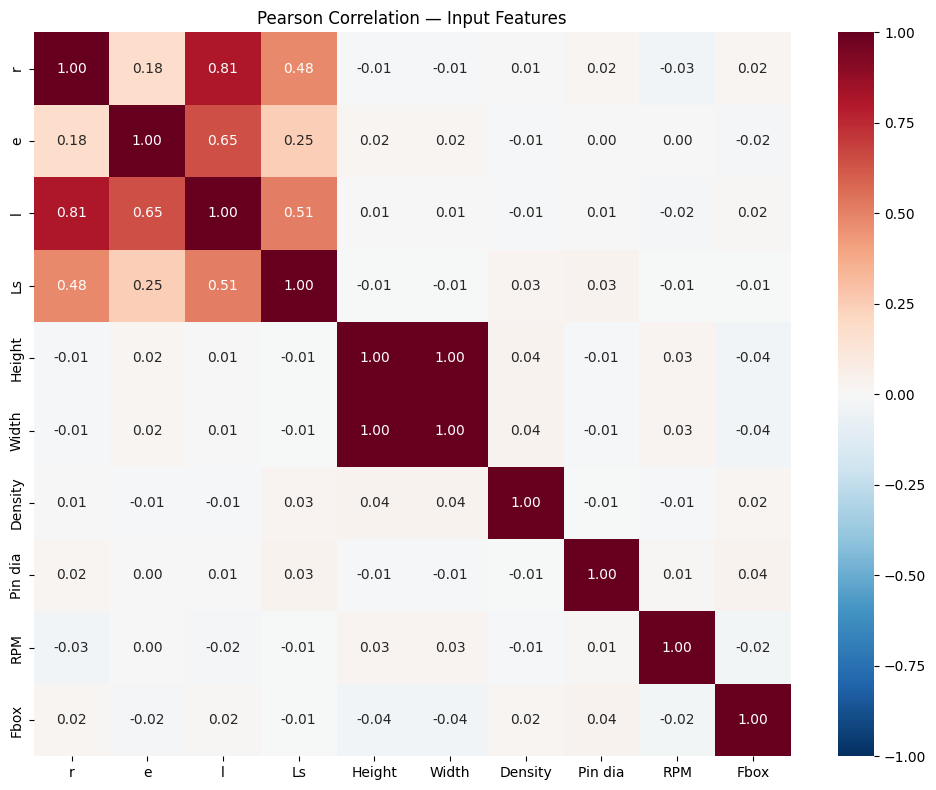

In [354]:
#Determine coefficient of relation for inputs using Pearson Correlation 

corr = df_training[input_col].corr(method='pearson')
threshold = 0.85
# for i in range(len(input_col)):
#     for j in range(i+1, len(input_col)):
#         r = corr.iloc[i, j]
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1)
plt.title('Pearson Correlation — Input Features')
plt.tight_layout()
plt.show()

In [355]:
#Defining the class, this is useful for the dataloader to load the data under certain categories(Training, Validation and testing)
class Training(Dataset):
    def __init__(self, x_mix, y_mix):
        assert x_mix.shape[0] == y_mix.shape[0]
        self.x_mix = x_mix
        self.y_mix = y_mix
    def __len__(self): return self.x_mix.shape[0]
    def __getitem__(self, idx): return self.x_mix[idx], self.y_mix[idx]

class Validation(Dataset):
    def __init__(self, x, y):
        assert x.shape[0] == y.shape[0]
        self.x = x
        self.y = y
    def __len__(self): return self.x.shape[0]
    def __getitem__(self, idx): return self.x[idx], self.y[idx]

class Testing(Dataset):
    def __init__(self, x, y):
        assert x.shape[0] == y.shape[0]
        self.x = x
        self.y = y
    def __len__(self): return self.x.shape[0]
    def __getitem__(self, idx): return self.x[idx], self.y[idx]


def get_dataloaders(train_ds,val_ds,test_ds,batch_size,num_workers,seed) -> tuple[DataLoader, DataLoader]:
    g = torch.Generator().manual_seed(seed)
    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=num_workers,
        generator=g,
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=num_workers,
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        num_workers=num_workers,
    )
    return train_loader, val_loader, test_loader

In [356]:
#Splitting of the data using random seed train_test_split from Sklearn which allows for reproductivity of the results for a given random seed value. 
def split_data(x, y, seed, train_frac=0.70, val_frac=0.15):
    n = len(x)
    test_frac = 1.0 - train_frac - val_frac
    indices = np.arange(n)
    train_idx, valtest_idx = train_test_split(indices, test_size=val_frac + test_frac, random_state=seed)
    relative_test = test_frac / (val_frac + test_frac)
    val_idx, test_idx = train_test_split(valtest_idx, test_size=relative_test, random_state=seed)
    return (torch.tensor(train_idx), torch.tensor(val_idx),torch.tensor(test_idx))

def mixup(x, y, alpha=alpha, seed=seed):
    np.random.seed(seed)
    N     = x.size(0)
    lam   = np.random.beta(alpha, alpha, size=N)
    lam   = np.maximum(lam, 1 - lam)
    lam_t = torch.tensor(lam, dtype=torch.float32).unsqueeze(1)
    idx_p = torch.randperm(N)
    x_mix = lam_t*x+(1-lam_t)*x[idx_p]
    y_mix = lam_t*y+(1-lam_t)*y[idx_p]
    return x_mix, y_mix

train_idx, val_idx, test_idx = split_data(x, y, seed)

In [357]:
#We define the architecture of the hidden layers we use layer normalization instead of batch normalization as it is more effective for small batch sizes and also works well with any batch size. We use ReLU as the activation function as recommended by Dr. Ince. We also use dropout to prevent overfitting by randomly deactivating neurons during training. The weights of the linear layers are initialized using Kaiming uniform initialization, which is suitable for ReLU activations, and biases are initialized to zero.
class Sohoite(nn.Module):
    def __init__(self,input_dim,n_output=n_output,dropout=dropout):
        super().__init__()
        self.hidden1 = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.hidden2 = nn.Sequential(
            nn.Linear(64,64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.drop  = nn.Dropout(dropout)
        self.skip = nn.Linear(input_dim,64)
        self.heads = nn.ModuleList([nn.Linear(64,1) for _ in range(n_output)])
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m,nn.Linear):
                nn.init.kaiming_uniform_(m.weight,nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
    def forward(self, x):
        h1  = self.hidden1(x)
        h2  = self.drop(self.hidden2(h1) + self.skip(x))
        return torch.cat([head(h2) for head in self.heads], dim=1)
    
    
""""
Notes from PyTorch Documentation and Class 
- Linear is the based feature of any code 
- LayerNorm: normalizes the values, and works better for small batches but also of any sizes. It is slow compared to BatchNorm 
- Relu: This is the activation function recommended by Dr. Ince
- Dropout: is a strategy to disable a neuron during training for reductancy. It can also be set at zero

Before starting, the code has to initialize the weights. 
""" 

'"\nNotes from PyTorch Documentation and Class \n- Linear is the based feature of any code \n- LayerNorm: normalizes the values, and works better for small batches but also of any sizes. It is slow compared to BatchNorm \n- Relu: This is the activation function recommended by Dr. Ince\n- Dropout: is a strategy to disable a neuron during training for reductancy. It can also be set at zero\n\nBefore starting, the code has to initialize the weights. \n'

In [358]:
#Here we define the training,evaluation and testing function. How it will keep track of the loss function and the metrics. We also use gradient clipping to prevent exploding gradients, which can occur when training deep networks. By setting a maximum norm for the gradients, we ensure that they do not become too large, which can destabilize training. The evaluation function is decorated with @torch.no_grad() to disable gradient calculations during evaluation, which reduces memory usage and speeds up computations since we don't need to compute gradients when evaluating the model's performance on the validation or test set.
def train_force_epoch(model, loader, optimizer, device, criterion):
    model.train()
    total_loss = 0.0
    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        pred = model(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(x_batch)
    return total_loss / len(loader.dataset)

@torch.no_grad()
def evaluate_force(model, loader, device, criterion):
    model.eval()
    total_loss = 0.0
    all_pred, all_true = [], []
    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        pred = model(x_batch)
        total_loss += criterion(pred, y_batch).item() * len(x_batch)
        all_pred.append(pred.cpu())
        all_true.append(y_batch.cpu())

    return (total_loss / len(loader.dataset),torch.cat(all_pred), torch.cat(all_true),)

def tester_force(y_pred_norm, y_true_norm, y_mean, y_std, cols):
    y_pred = (y_pred_norm * y_std + y_mean).numpy()
    y_true = (y_true_norm * y_std + y_mean).numpy()
    results = {}
    for i, col in enumerate(cols):
        err    = y_pred[:, i] - y_true[:, i]
        mae    = float(np.mean(np.abs(err)))
        rmse   = float(np.sqrt(np.mean(err ** 2)))
        ss_res = np.sum(err ** 2)
        ss_tot = np.sum((y_true[:, i] - y_true[:, i].mean()) ** 2)
        r2     = float(1 - ss_res / (ss_tot + 1e-8))
        results[col] = {'mae': mae, 'rmse': rmse, 'r2': r2}
    mean_r2 = float(np.mean([v['r2'] for v in results.values()]))
    return results, mean_r2

#AI Written & recommended
device = torch.device( 'mps' 
 if torch.backends.mps.is_available() 
    else
    'cuda' if torch.cuda.is_available()          
    else
    'cpu'
) 


In [359]:
#Normalize the data such that it shows from [0,1] and makes it more stable and is better for dataset where features have different scales. 
x_tr  = x[train_idx]; 
y_tr  = y[train_idx];   
x_val = x[val_idx];  
y_val = y[val_idx];  
x_te  = x[test_idx]; 
y_te  = y[test_idx]; 

x_mean = x_tr.mean(dim=0)
x_std  = x_tr.std(dim=0).clamp(min=1e-8)
y_mean = y_tr.mean(dim=0)
y_std = y_tr.std(dim=0).clamp(min=1e-8)

x_tr_norm = (x_tr  - x_mean) / x_std
x_val_norm = (x_val - x_mean) / x_std
x_te_norm  = (x_te  - x_mean) / x_std
y_tr_norm  = (y_tr  - y_mean) / y_std
y_val_norm = (y_val - y_mean) / y_std
y_te_norm  = (y_te  - y_mean) / y_std

In [360]:
#Here we define how we call on the dataloader to load the data for what is needed. Then it will call on the model architecture and the optimizer to train the model and evaluate it. It keeps tracks of the loss history and has an early stop to avoid overfitting. 

val_ds = Validation(x_val_norm,y_val_norm)
test_ds = Testing (x_te_norm,y_te_norm)
val_loader =DataLoader(val_ds,batch_size=batch_size,shuffle=False,num_workers=0)
test_loader = DataLoader(test_ds,batch_size=batch_size,shuffle=False,num_workers=0)

Sohoite_model=Sohoite(input_dim=x.shape[1]).to(device)


# !!  Learning Rate  !! Configuration

# # # Option 1: AdamW  (Adjusted Learning Rate)
optimizer = torch.optim.AdamW(Sohoite_model.parameters(), lr=1e-3, weight_decay=1e-3)


##  Option 2: Adam  (Fixed Learning Rate)
# optimizer = torch.optim.Adam(Sohoite_model.parameters(), lr=1e-4)

best_force_val    = float('inf')
best_force_state  = None
epochs_no_improve = 0
stopped_force     = epochs
force_train_hist  = []
force_val_hist    = []

#Validation is used to test the model. Afer the model is done, we have a testing set to obtain the performance of the model on fully unseen data. 
print(f"\n{'-'*25}")
print(f"{'Epoch':>15} | {'Training Loss':>12} | {'Validation Loss':>12} ")
print(f"\n{'-'*25}")
for epoch in range(1,epochs+1):
    x_mix, y_mix = mixup(x_tr_norm,y_tr_norm,alpha=alpha,seed=epoch)
    train_ds = Training(x_mix, y_mix)
    train_loader, _,_ = get_dataloaders(train_ds,val_ds,test_ds,batch_size=batch_size,num_workers=0,seed=epoch) #using seed=epoch adds more randomness to the mixup for each epoch improving performance. 
    tr_loss = train_force_epoch(Sohoite_model,train_loader,optimizer,device,criterion)
    val_loss, _, _  = evaluate_force(Sohoite_model,val_loader,device,criterion)
    force_train_hist.append(tr_loss)
    force_val_hist.append(val_loss)
    if val_loss < best_force_val:
        best_force_val = val_loss
        best_force_state = {k:v.clone() for k, v in Sohoite_model.state_dict().items()}
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1 #print values for every 50 epochs and first epoch to see the progress
    if epoch % 50 == 0 or epoch == 1:
        print(f'  {epoch:>6} | {tr_loss:>12.6f} | {val_loss:>10.6f} ')
    if epochs_no_improve >= patience:
        stopped_force = epoch
        break

print(f'\nStopped: epoch {stopped_force}')
Sohoite_model.load_state_dict(best_force_state)


-------------------------
          Epoch | Training Loss | Validation Loss 

-------------------------
       1 |     1.241484 |   0.770813 
      50 |     0.312814 |   0.333038 
     100 |     0.244091 |   0.236952 
     150 |     0.222965 |   0.202823 
     200 |     0.203466 |   0.179990 
     250 |     0.203836 |   0.166216 
     300 |     0.197129 |   0.157506 
     350 |     0.194818 |   0.152118 

Stopped: epoch 358


<All keys matched successfully>

In [361]:
#Testing
test_loss, test_pred, test_true = evaluate_force(Sohoite_model, test_loader, device, criterion)
results, mean_r2 = tester_force(test_pred, test_true, y_mean, y_std, out_col)

print(f"\n{'='*25}")
print(f" Test Results ")
print(f"{'='*25}")
print(f"  {'Column':<15} {'MAE':>12} {'RMSE':>12} {'R²':>10}")
print(f"  {'-'*49}")
for col, m in results.items():
    print(f"  {col:<15} {m['mae']:>12.4f} {m['rmse']:>12.4f} {m['r2']:>10.4f}")
print(f"  {'-'*25}")
print(f"  {'Mean R2':<15} {mean_r2:>12.4f}")
print(f"  Test {criterion} Loss : {test_loss:.6f}")
print(f"{'='*25}")

y_pred_real = (test_pred * y_std + y_mean).numpy()
y_true_real = (test_true * y_std + y_mean).numpy()
n_targets = len(out_col)


 Test Results 
  Column                   MAE         RMSE         R²
  -------------------------------------------------
  |P1| Max             60.9448     139.8342     0.8713
  |B0| Max             54.7829     124.7146     0.8731
  FOS                   0.0617       0.0932     0.9604
  Torque                8.2620      15.3742     0.9293
  QRR                   0.0424       0.0739     0.9294
  dx                    0.0122       0.0163     0.9993
  Bearing          412970.7812  742136.6875     0.8754
  -------------------------
  Mean R2               0.9197
  Test L1Loss() Loss : 0.141232


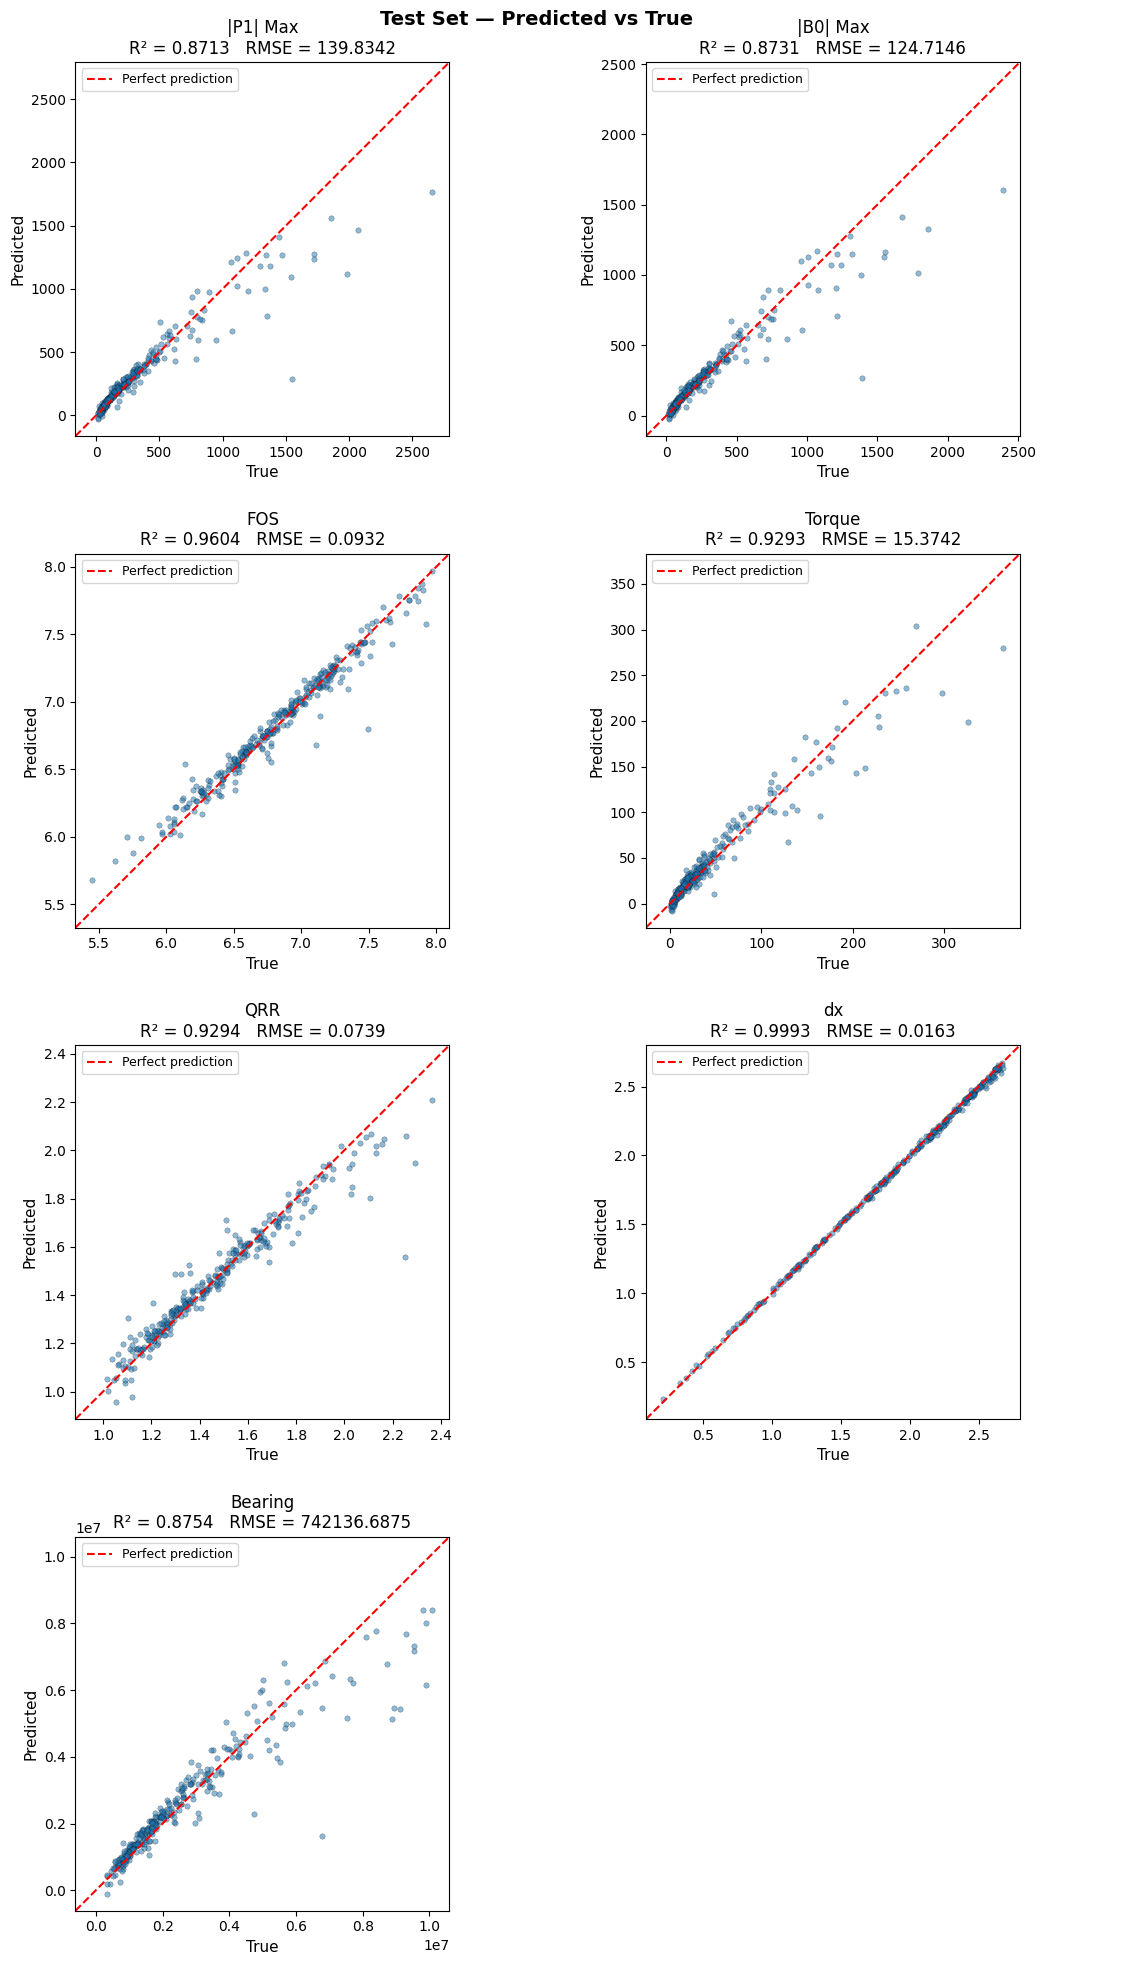

In [362]:
#Ai written part to plot the graphs of the data. Ai written to save time and make it look more professional. 

n_cols = 2
n_rows = math.ceil(n_output / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten() if n_output > 1 else [axes]
for i in range(n_output):
    col = out_col[i]
    ax = axes[i]
    ax.scatter(y_true_real[:, i], y_pred_real[:, i], alpha=0.5, s=15, edgecolors='k', linewidth=0.3)
    # Calculate limits for the identity line
    lims = [min(y_true_real[:, i].min(), y_pred_real[:, i].min()),
            max(y_true_real[:, i].max(), y_pred_real[:, i].max())]
    margin = (lims[1] - lims[0]) * 0.05
    lims = [lims[0] - margin, lims[1] + margin]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('True', fontsize=11)
    ax.set_ylabel('Predicted', fontsize=11)
    ax.set_title(f'{col}\nR² = {results[col]["r2"]:.4f}   RMSE = {results[col]["rmse"]:.4f}', fontsize=12)
    ax.legend(fontsize=9)
    ax.set_aspect('equal')

# Clean up: hide any empty subplots if n_outputs is odd
for j in range(n_output, len(axes)):
    axes[j].axis('off')
fig.suptitle('Test Set — Predicted vs True', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [363]:
#Save Model
save_directory = "saved_model"
os.makedirs(save_directory, exist_ok=True)
torch.save({
    'model_state_dict': Sohoite_model.state_dict(),
    'x_mean': x_mean,                  
    'x_std': x_std,                
    'y_mean': y_mean,                   
    'y_std': y_std,              
    'input_col': input_col,
    'out_col': out_col,      
    'n_input': len(input_col),
    'n_output': len(out_col),
}, 
os.path.join(save_directory, 'Sohoite_predictor.pt'))
print("Model saved to:", os.path.join(save_directory, 'Sohoite_predictor.pt'))

Model saved to: saved_model/Sohoite_predictor.pt


In [372]:
y_mean_d = y_mean.to(device)
y_std_d  = y_std.to(device)
candidates = []
attempts   = 0

while len(candidates) < 5 and attempts < 500_000:
    attempts += 1

    r       = random.uniform(0.036, 0.7440)
    e       = random.uniform(0.002, 0.4070)
    l       = random.uniform(0.1003, 0.999)
    Ls      = random.uniform(0.1498, 1.8994)
    Height  = random.uniform(0.015, 0.0350)
    Width   = random.uniform(0.005, 0.0117)
    Pin_dia = random.uniform(0.004, 0.008)

    # Formula check first — skip model if dx is already wrong
    dx_check = l * 1.5 * math.cos(math.radians(20)) - 3 * Width
    if abs(dx_check - 0.250) > 0.005:
        continue

    x_input = torch.tensor([[r, e, l, Ls, Height, Width, 2700.0, Pin_dia, 30.0, 4.5]])
    x_norm  = (x_input - x_mean) / x_std

    with torch.no_grad():
        y_norm = Sohoite_model(x_norm.to(device))

    y_pred   = (y_norm * y_std_d + y_mean_d).cpu().numpy()[0]
    pred_QRR = y_pred[out_col.index('QRR')]
    pred_dx  = y_pred[out_col.index('dx')]

    # Only accept if QRR in range AND formula vs model dx agree within 10%
    if (1.5 <= pred_QRR <= 2.5
            and r < l/3
            and abs(dx_check - pred_dx)/dx_check <= 0.1):
        candidates.append({
            'r': r, 'e': e, 'l': l, 'Ls': Ls,
            'Height': Height, 'Width': Width,
            'Density': 2700.0, 'Pin dia': Pin_dia,
            'RPM': 30.0, 'Fbox': 4.5,
            'dx_formula': round(dx_check, 4),
            **{out_col[i]: round(y_pred[i], 4) for i in range(len(out_col))}
        })

df_configs = pd.DataFrame(candidates, index=range(1, len(candidates)+1))
df_configs.index.name = 'Config'

out_file = "configurations_5.xlsx"
with pd.ExcelWriter(out_file, engine='openpyxl') as writer:
    df_configs[::].to_excel(writer, sheet_name='Model')

print(f"Found {len(candidates)} configurations after {attempts} attempts")
print(df_configs.to_string())

Found 1 configurations after 500000 attempts
               r         e         l        Ls    Height     Width  Density   Pin dia   RPM  Fbox  dx_formula    |P1| Max    |B0| Max     FOS  Torque     QRR      dx      Bearing
Config                                                                                                                                                                            
1       0.059933  0.224551  0.188024  0.165669  0.018347  0.005488   2700.0  0.005721  30.0   4.5      0.2486  160.354004  142.074707  6.4938 -8.3156  2.1744  0.2305  1436725.375


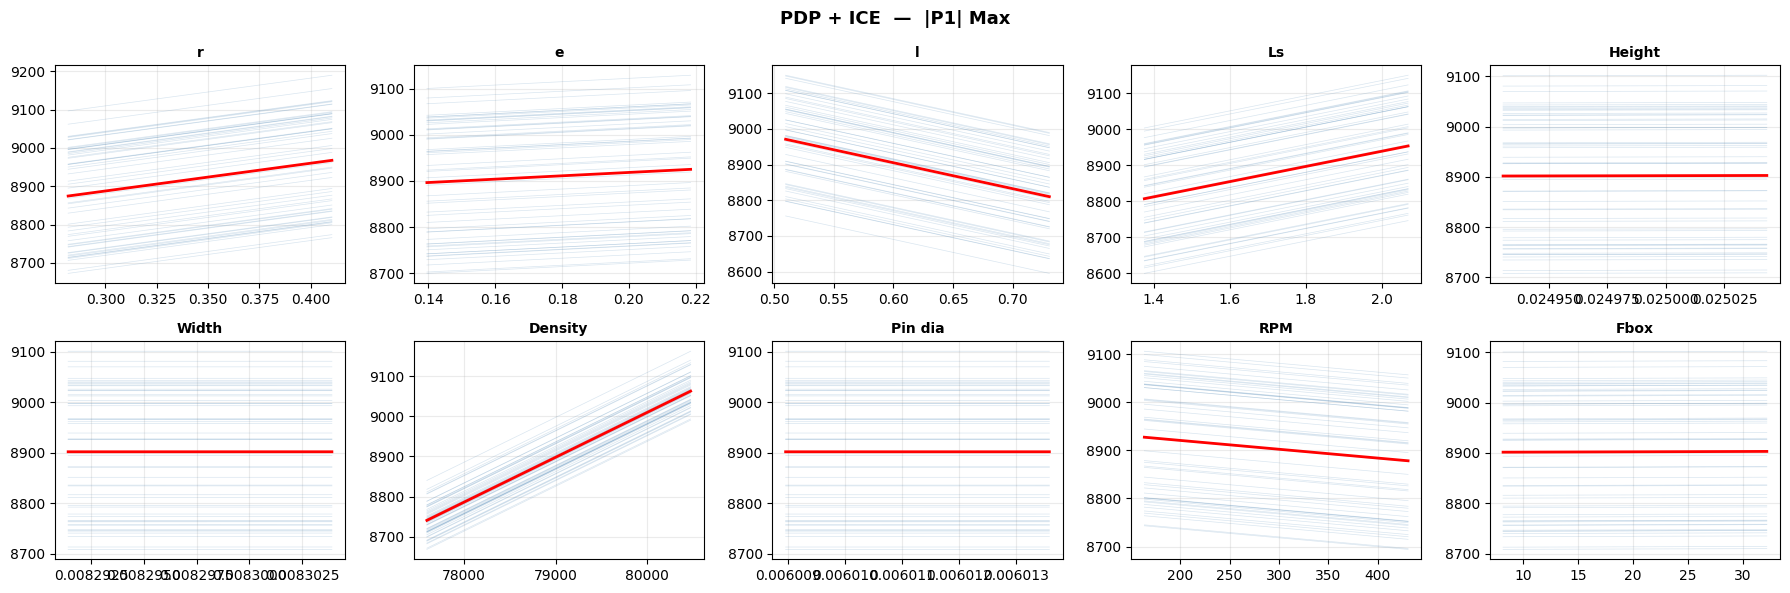

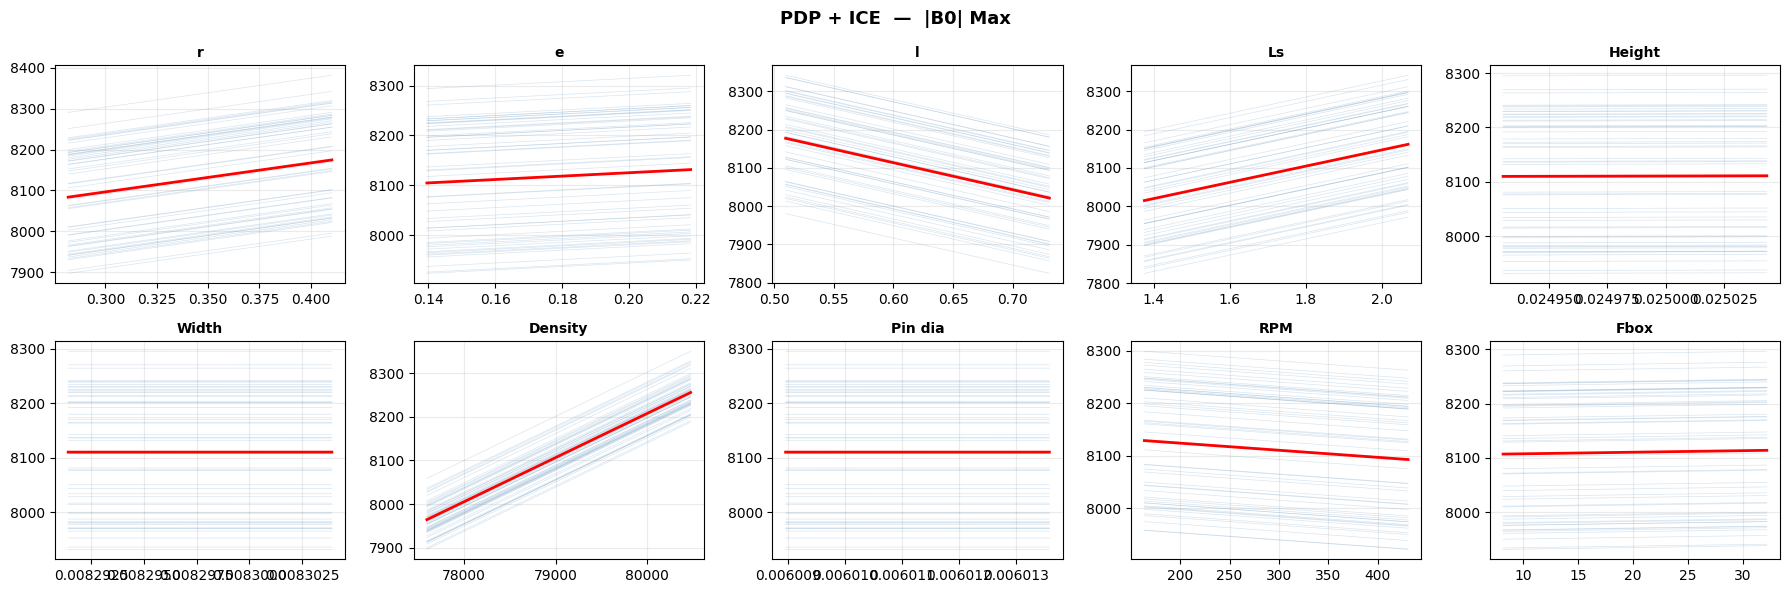

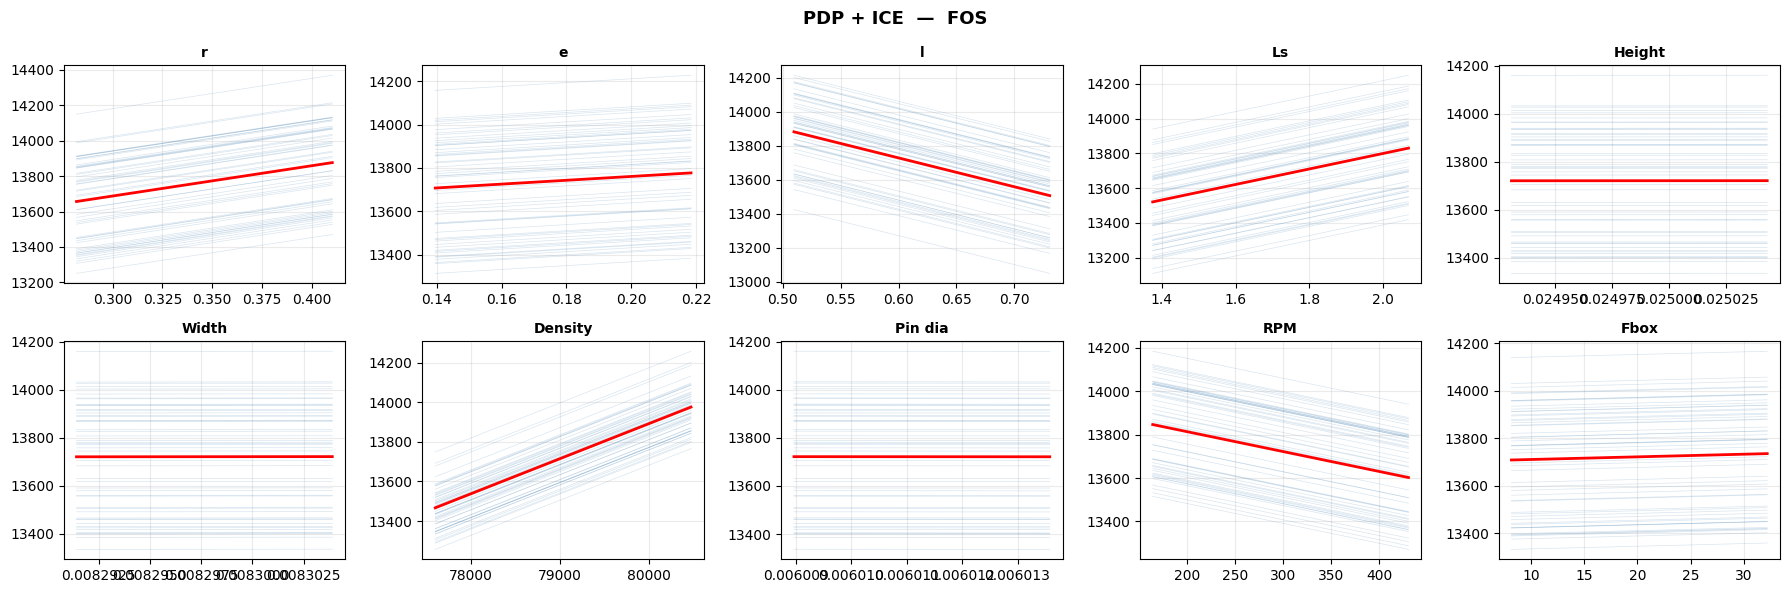

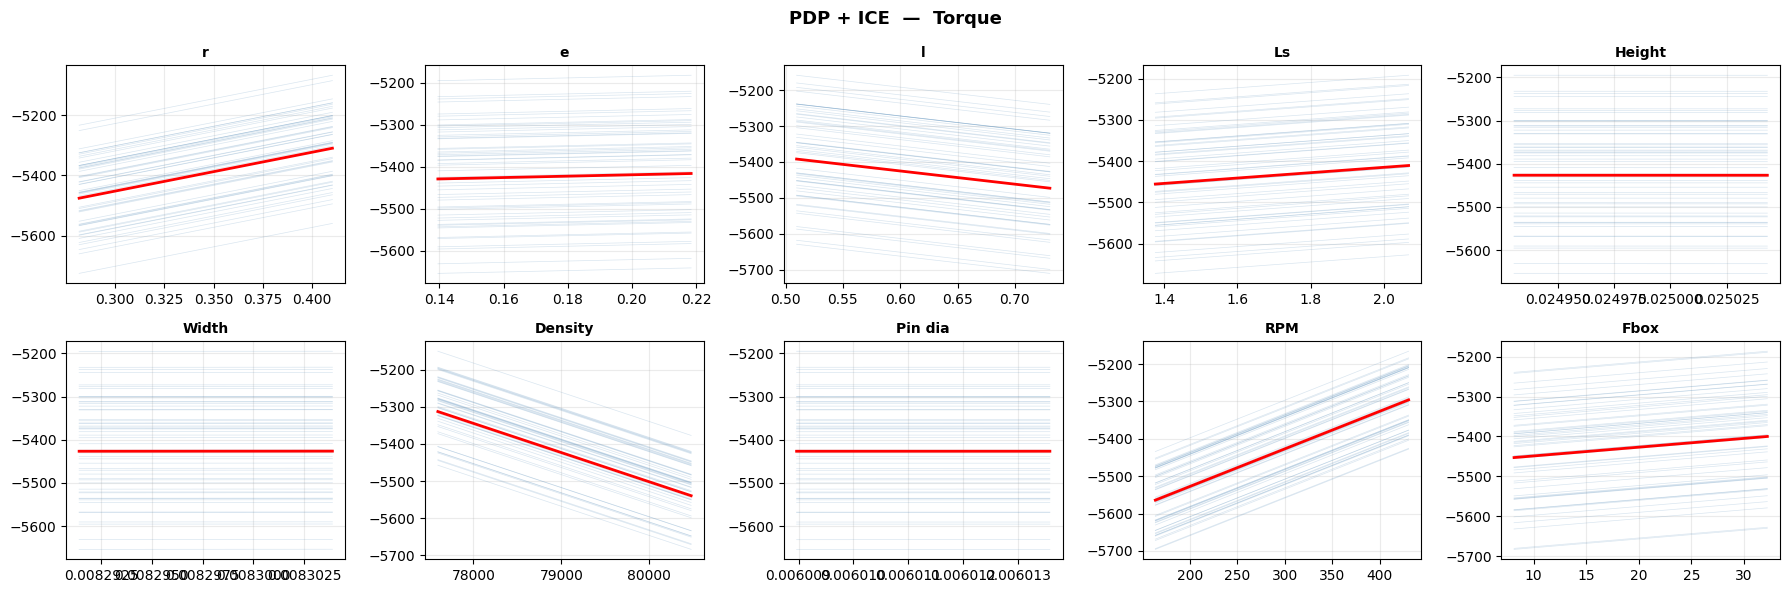

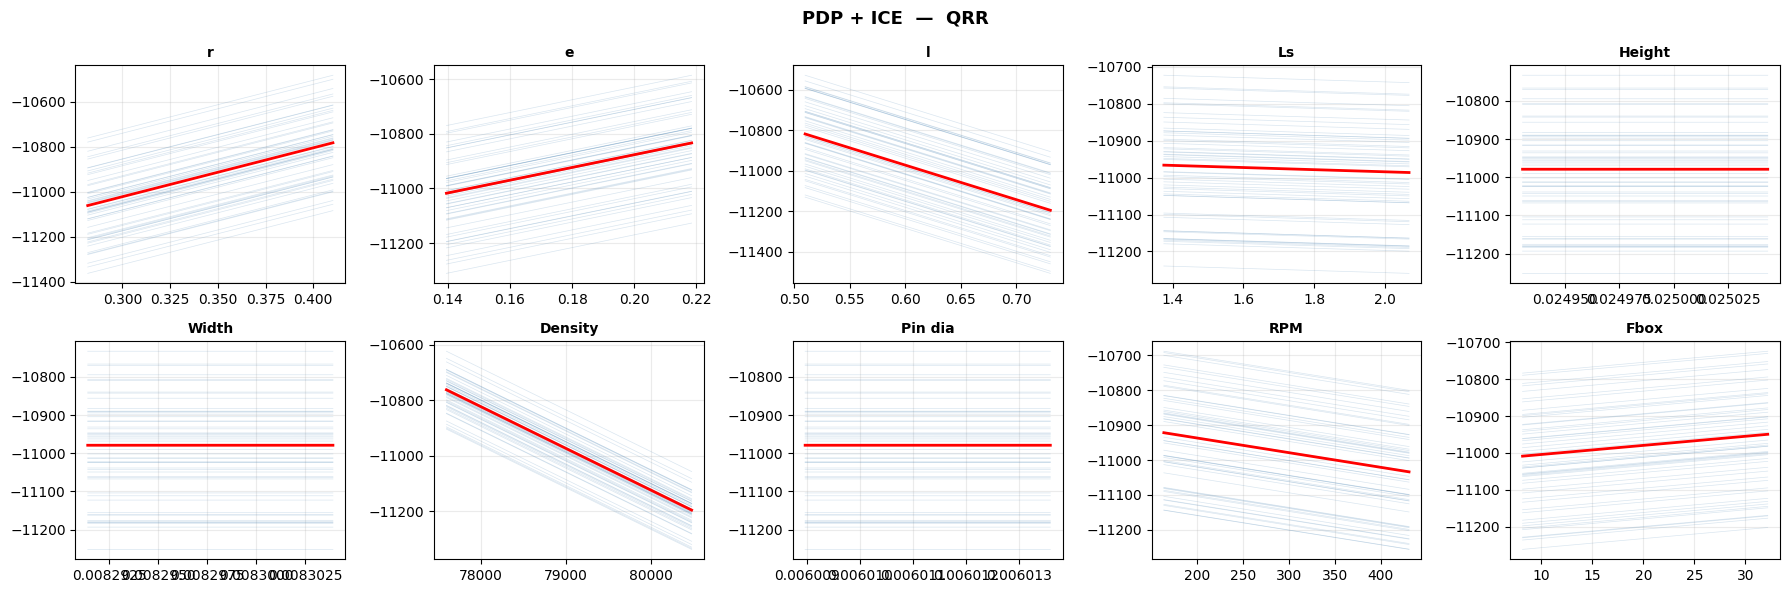

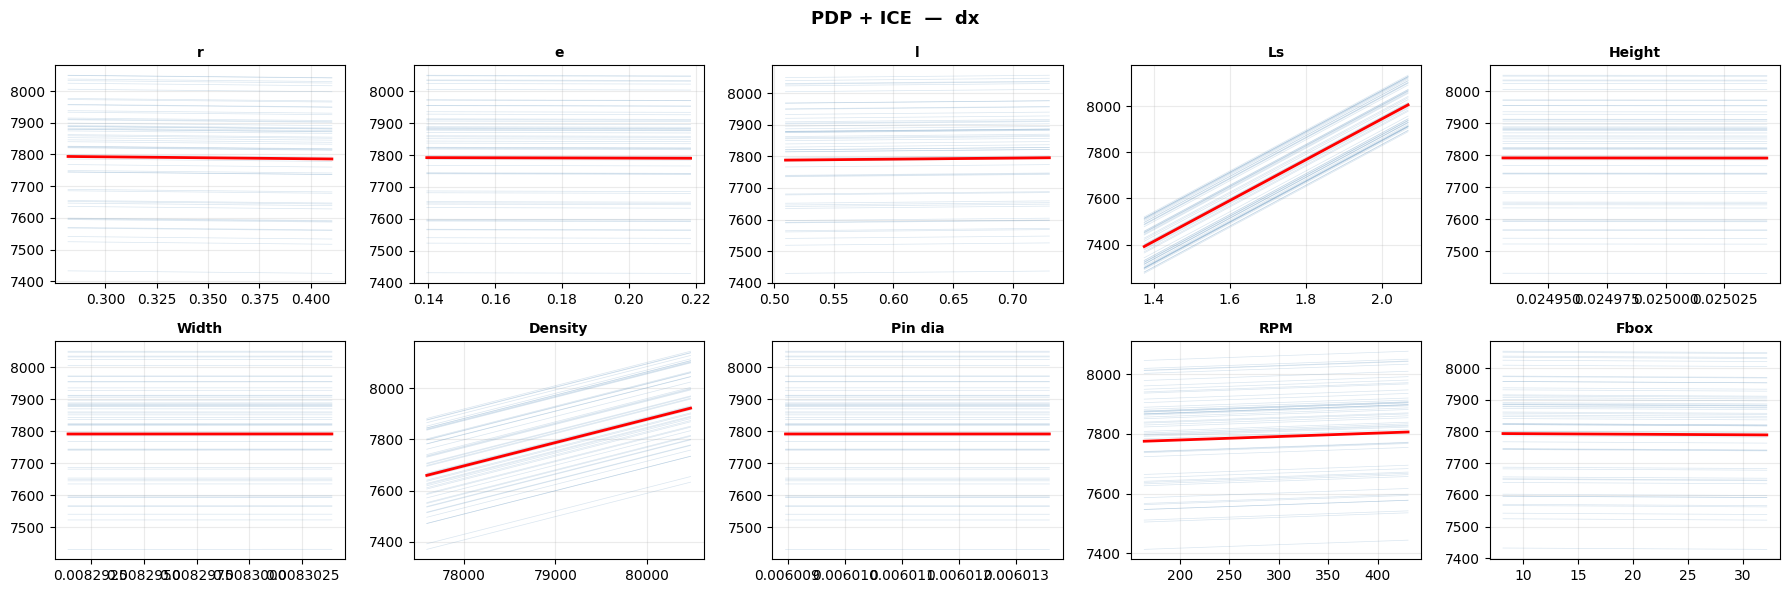

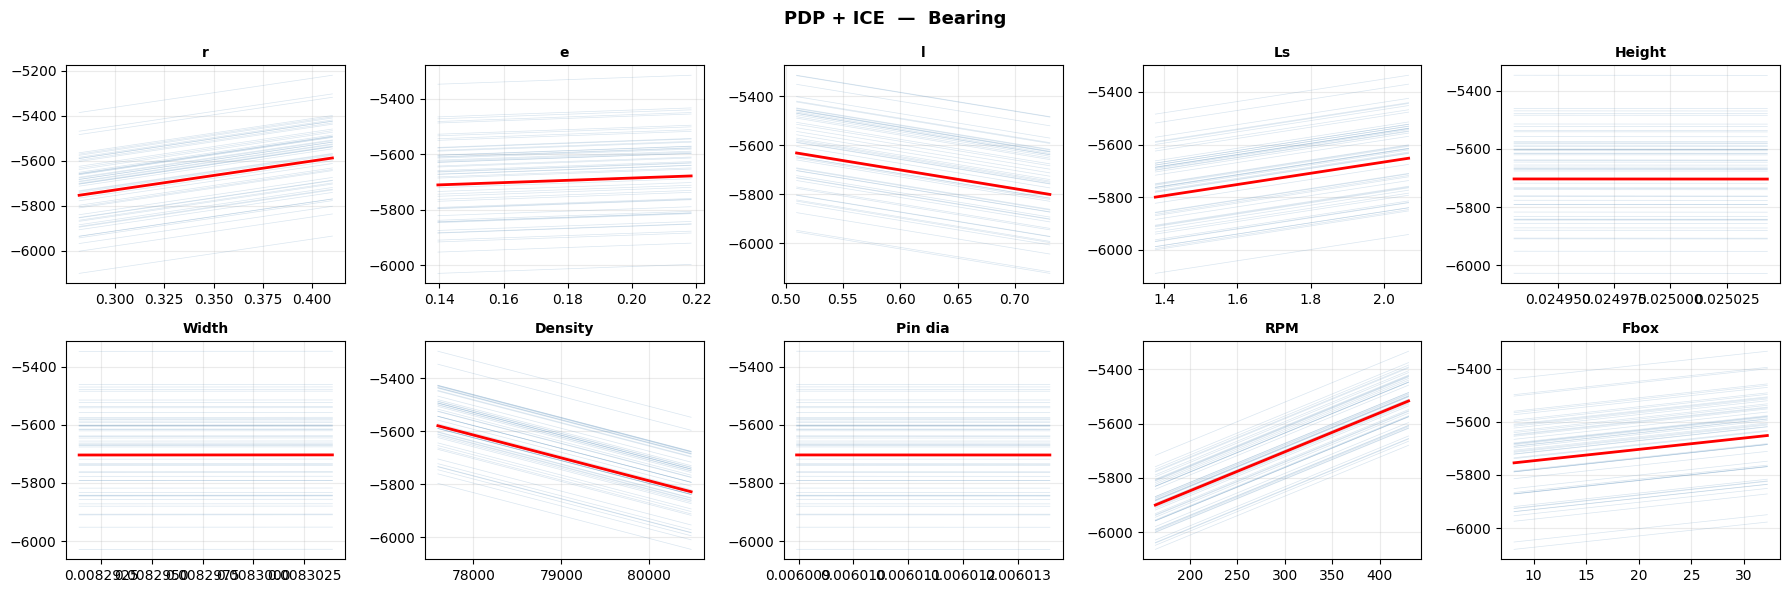

In [ ]:
X_real = (x_tr * x_std + x_mean).numpy()

def pdp(X, feat_idx, output_idx, n_grid=20):
    grid = np.linspace(X[:, feat_idx].min(), X[:, feat_idx].max(), n_grid)
    curves = np.zeros((len(X), n_grid))
    for i, val in enumerate(grid):
        X_tmp = X.copy()
        X_tmp[:, feat_idx] = val
        X_t = torch.tensor(X_tmp, dtype=torch.float32).to(device)  # ← send to device
        with torch.no_grad():
            y = Sohoite_model((X_t - x_mean.to(device)) / x_std.to(device))
        curves[:, i] = (y[:, output_idx] * y_std[output_idx] + y_mean[output_idx]).cpu().numpy()
    return grid, curves

for oi, out_name in enumerate(out_col):
    fig, axes = plt.subplots(2, 5, figsize=(18, 6))
    for fi, feat_name in enumerate(input_col):
        ax = axes.flatten()[fi]
        grid, curves = pdp(X_real, fi, oi)
        for curve in curves[::max(1, len(curves)//50)]:ax.plot(grid, curve, color='steelblue', alpha=0.2, linewidth=0.5)
        ax.plot(grid, curves.mean(axis=0), color='red', linewidth=2)
        ax.set_title(feat_name, fontsize=10, fontweight='bold')
        ax.grid(alpha=0.25)
    fig.suptitle(f'PDP  {out_name}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [366]:

import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import openpyxl as pxl
import pandas as pd

# ── 0.  Paths & config ───────────────────────────────────────────────────────
CHECKPOINT  = "saved_model/Sohoite_predictor.pt"
DATA_FILE   = os.path.join("Data", f"{File_name}.xlsx")
OUT_DIR     = "results_pdp"
SEED        = 42
N_ICE       = 300        # number of rows used for ICE curves
N_GRID      = 60         # grid points swept per feature
# 2-D interaction pairs — edit to taste
INTERACTION_PAIRS = [
    ("r",      "l"),
    ("RPM",    "Fbox"),
    ("Height", "Width"),
]
os.makedirs(OUT_DIR, exist_ok=True)

# ── 1.  Sohoite architecture ─────────────────────────────────────────────────
class Sohoite(nn.Module):
    def __init__(self, input_dim, n_output, dropout=0.1):
        super().__init__()
        self.hidden1 = nn.Sequential(
            nn.Linear(input_dim, 64), nn.LayerNorm(64), nn.ReLU(), nn.Dropout(dropout))
        self.hidden2 = nn.Sequential(
            nn.Linear(64, 64), nn.LayerNorm(64), nn.ReLU(), nn.Dropout(dropout))
        self.skip  = nn.Linear(input_dim, 64)
        self.heads = nn.ModuleList([nn.Linear(64, 1) for _ in range(n_output)])
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        h1 = self.hidden1(x)
        h2 = self.hidden2(h1) + self.skip(x)
        return torch.cat([head(h2) for head in self.heads], dim=1)

# ── 2.  Load checkpoint ──────────────────────────────────────────────────────
ckpt       = torch.load(CHECKPOINT, map_location="cpu")
input_col  = ckpt["input_col"]
out_col = ckpt["out_col"]
x_mean     = ckpt["x_mean"]
x_std      = ckpt["x_std"]
y_mean     = ckpt["y_mean"]
y_std      = ckpt["y_std"]
n_input    = len(input_col)
n_output   = len(out_col)

model = Sohoite(input_dim=n_input, n_output=n_output)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded Sohoite  —  {n_input} inputs, {n_output} outputs")

# ── 3.  Predict in real space ────────────────────────────────────────────────
def predict_real(X_np):
    """
    X_np : (n, n_input)  float32 numpy, real (un-normalised) space
    returns (n, n_output) float32 numpy, real space
    """
    X_t    = torch.tensor(X_np.astype(np.float32))
    X_norm = (X_t - x_mean) / x_std
    with torch.no_grad():
        y_norm = model(X_norm)
    return (y_norm * y_std + y_mean).numpy()

# ── 4.  Load & clean data ─────────────────────────────────────────────────────
wb   = pxl.load_workbook(DATA_FILE, data_only=True)
ws   = wb.active
hdrs = [ws.cell(1, c).value for c in range(1, ws.max_column + 1)]
rows = list(ws.iter_rows(min_row=2, values_only=True))
df   = pd.DataFrame(rows, columns=hdrs).drop(columns=[None], errors="ignore").dropna()
X_real = df[input_col].values.astype(np.float32)
print(f"Dataset loaded  —  {len(X_real)} rows")

# ── 5.  ICE sample ───────────────────────────────────────────────────────────
rng   = np.random.default_rng(SEED)
idx   = rng.choice(len(X_real), size=min(N_ICE, len(X_real)), replace=False)
X_ice = X_real[idx]                         # (N_ICE, n_input)
print(f"ICE sample: {len(X_ice)} rows\n")

# ── 6.  Core ICE computation ─────────────────────────────────────────────────
def compute_ice(X_sample, feat_idx, grid):
    """
    Sweep feature `feat_idx` over `grid` (length G), holding all other
    features at their row values.

    Returns
    -------
    ice_mat : (N_sample, G, n_output)  — raw ICE predictions per row & grid pt
    pdp     : (G, n_output)            — mean over rows (PDP)
    """
    N, G = len(X_sample), len(grid)
    ice_mat = np.empty((N, G, n_output), dtype=np.float32)
    for gi, gv in enumerate(grid):
        X_tmp = X_sample.copy()
        X_tmp[:, feat_idx] = gv
        ice_mat[:, gi, :] = predict_real(X_tmp)
    pdp = ice_mat.mean(axis=0)              # (G, n_output)
    return ice_mat, pdp

def feat_grid(feat_idx, n_points=N_GRID):
    lo, hi = X_real[:, feat_idx].min(), X_real[:, feat_idx].max()
    return np.linspace(lo, hi, n_points)

def units(name):
    return {"r":"(m)","e":"(m)","l":"(m)","Ls":"(m)",
            "Height":"(m)","Width":"(m)","Density":"(kg/m³)",
            "Pin dia":"(m)","RPM":"(rpm)","Fbox":"(-)"}.get(name,"")

# ── 7.  Individual PDP+ICE plots ─────────────────────────────────────────────
print("Generating individual PDP+ICE plots …")
for fi, feat_name in enumerate(input_col):
    feat_safe = feat_name.replace(" ", "_")
    grid      = feat_grid(fi)
    ice_mat, pdp = compute_ice(X_ice, fi, grid)   # (N_ICE, G, n_output)

    for oi, out_name in enumerate(out_col):
        out_safe = out_name.replace("|", "").replace(" ", "_")
        ice_o    = ice_mat[:, :, oi]               # (N_ICE, G)
        pdp_o    = pdp[:, oi]                      # (G,)
        p10      = np.percentile(ice_o, 10, axis=0)
        p90      = np.percentile(ice_o, 90, axis=0)

        fig, ax = plt.subplots(figsize=(7, 4.5))

        # ICE lines (thin, semi-transparent)
        for row in ice_o:
            ax.plot(grid, row, color="steelblue", alpha=0.06, linewidth=0.7)

        # P10–P90 band
        ax.fill_between(grid, p10, p90, alpha=0.18, color="steelblue",
                        label="P10–P90 band")

        # PDP mean
        ax.plot(grid, pdp_o, color="tomato", linewidth=2.2,
                label="PDP (mean)", zorder=5)

        ax.set_xlabel(f"{feat_name}  {units(feat_name)}", fontsize=11)
        ax.set_ylabel(out_name, fontsize=11)
        ax.set_title(f"PDP + ICE  |  {feat_name}  →  {out_name}",
                     fontsize=12, fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(alpha=0.25)
        plt.tight_layout()
        fig.savefig(
            os.path.join(OUT_DIR, f"pdp_ice_{feat_safe}_{out_safe}.png"), dpi=130)
        plt.close(fig)

    print(f"  ✓  {feat_name}")

# ── 8.  Small-multiples grid per output ──────────────────────────────────────
print("\nGenerating per-output grid plots …")
ncols = 3
nrows = -(-n_input // ncols)

for oi, out_name in enumerate(out_col):
    out_safe = out_name.replace("|", "").replace(" ", "_")
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
    axes_flat = axes.flatten()

    for fi, feat_name in enumerate(input_col):
        ax   = axes_flat[fi]
        grid = feat_grid(fi)
        ice_mat, pdp = compute_ice(X_ice, fi, grid)
        ice_o = ice_mat[:, :, oi]
        pdp_o = pdp[:, oi]
        p10   = np.percentile(ice_o, 10, axis=0)
        p90   = np.percentile(ice_o, 90, axis=0)

        for row in ice_o:
            ax.plot(grid, row, color="steelblue", alpha=0.05, linewidth=0.5)
        ax.fill_between(grid, p10, p90, alpha=0.18, color="steelblue")
        ax.plot(grid, pdp_o, color="tomato", linewidth=2.0)
        ax.set_title(feat_name, fontsize=10, fontweight="bold")
        ax.set_xlabel(units(feat_name), fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.2)

    for ax in axes_flat[n_input:]:
        ax.set_visible(False)

    fig.suptitle(f"PDP + ICE Overview  —  {out_name}",
                 fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    fig.savefig(
        os.path.join(OUT_DIR, f"pdp_grid_{out_safe}.png"),
        dpi=130, bbox_inches="tight")
    plt.close(fig)
    print(f"  ✓  {out_name}")

# ── 9.  2-D interaction PDP heatmaps ─────────────────────────────────────────
print("\nGenerating 2-D interaction PDPs …")
bg_idx = rng.choice(len(X_real), size=min(100, len(X_real)), replace=False)
X_bg   = X_real[bg_idx]

for oi, out_name in enumerate(out_col):
    out_safe = out_name.replace("|", "").replace(" ", "_")

    for (fa, fb) in INTERACTION_PAIRS:
        if fa not in input_col or fb not in input_col:
            print(f"  Skipping ({fa}, {fb}) — not in input_col")
            continue
        ia, ib  = input_col.index(fa), input_col.index(fb)
        grid_a  = feat_grid(ia, N_GRID)
        grid_b  = feat_grid(ib, N_GRID)
        Z       = np.zeros((N_GRID, N_GRID), dtype=np.float32)

        for i, av in enumerate(grid_a):
            for j, bv in enumerate(grid_b):
                X_tmp = X_bg.copy()
                X_tmp[:, ia] = av
                X_tmp[:, ib] = bv
                Z[j, i] = predict_real(X_tmp)[:, oi].mean()

        fig, ax = plt.subplots(figsize=(7, 5.5))
        cf   = ax.contourf(grid_a, grid_b, Z, levels=20, cmap="RdYlBu_r")
        cbar = fig.colorbar(cf, ax=ax)
        cbar.set_label(out_name, fontsize=10)
        ax.set_xlabel(f"{fa}  {units(fa)}", fontsize=11)
        ax.set_ylabel(f"{fb}  {units(fb)}", fontsize=11)
        ax.set_title(f"2-D PDP  |  {fa} × {fb}  →  {out_name}",
                     fontsize=12, fontweight="bold")
        plt.tight_layout()
        safe_a = fa.replace(" ", "_")
        safe_b = fb.replace(" ", "_")
        fig.savefig(
            os.path.join(OUT_DIR, f"interaction_{out_safe}_{safe_a}_{safe_b}.png"),
            dpi=130)
        plt.close(fig)

print(f"\nAll PDP+ICE plots saved to  '{OUT_DIR}/'")
print("Files written:")
for f in sorted(os.listdir(OUT_DIR)):
    print(f"  {f}")

Loaded Sohoite  —  10 inputs, 7 outputs
Dataset loaded  —  2166 rows
ICE sample: 300 rows

Generating individual PDP+ICE plots …
  ✓  r
  ✓  e
  ✓  l
  ✓  Ls
  ✓  Height
  ✓  Width
  ✓  Density
  ✓  Pin dia
  ✓  RPM
  ✓  Fbox

Generating per-output grid plots …
  ✓  |P1| Max
  ✓  |B0| Max
  ✓  FOS
  ✓  Torque
  ✓  QRR
  ✓  dx
  ✓  Bearing

Generating 2-D interaction PDPs …

All PDP+ICE plots saved to  'results_pdp/'
Files written:
  04_pdp_Bearing.png
  04_pdp_FOS.png
  04_pdp_Power.png
  04_pdp_QRR.png
  04_pdp_Torque.png
  04_pdp__B0__Max.png
  04_pdp__P1__Max.png
  04_pdp__RT0__Max.png
  04_pdp_dx.png
  interaction_B0_Max_Height_Width.png
  interaction_B0_Max_RPM_Fbox.png
  interaction_B0_Max_r_l.png
  interaction_Bearing_Height_Width.png
  interaction_Bearing_RPM_Fbox.png
  interaction_Bearing_r_l.png
  interaction_FOS_Height_Width.png
  interaction_FOS_RPM_Fbox.png
  interaction_FOS_r_l.png
  interaction_P1_Max_Height_Width.png
  interaction_P1_Max_RPM_Fbox.png
  interaction_P1_Ma

In [367]:

import os, numpy as np, torch, torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import openpyxl as pxl
import pandas as pd

# ── 0.  Paths & config ───────────────────────────────────────────────────────
CHECKPOINT   = "saved_model/Sohoite_predictor.pt"
DATA_FILE    = os.path.join("Data", f"{File_name}.xlsx")
OUT_DIR      = "results_shap"
SEED         = 42
N_BACKGROUND = 100    # rows fed into k-means summary for the background
                      # KernelExplainer is O(N_BACKGROUND × N_EXPLAIN),
                      # so keep N_BACKGROUND ≤ 100 and N_EXPLAIN ≤ 200
N_EXPLAIN    = 200    # rows to explain (None = all)
os.makedirs(OUT_DIR, exist_ok=True)

# ── 1.  Sohoite architecture ─────────────────────────────────────────────────
class Sohoite(nn.Module):
    def __init__(self, input_dim, n_output, dropout=0.1):
        super().__init__()
        self.hidden1 = nn.Sequential(
            nn.Linear(input_dim, 64), nn.LayerNorm(64), nn.ReLU(), nn.Dropout(dropout))
        self.hidden2 = nn.Sequential(
            nn.Linear(64, 64), nn.LayerNorm(64), nn.ReLU(), nn.Dropout(dropout))
        self.skip  = nn.Linear(input_dim, 64)
        self.heads = nn.ModuleList([nn.Linear(64, 1) for _ in range(n_output)])
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
                if m.bias is not None: nn.init.zeros_(m.bias)

    def forward(self, x):
        h1 = self.hidden1(x)
        h2 = self.hidden2(h1) + self.skip(x)
        return torch.cat([head(h2) for head in self.heads], dim=1)

# ── 2.  Load checkpoint ──────────────────────────────────────────────────────
ckpt       = torch.load(CHECKPOINT, map_location="cpu")
input_col  = ckpt["input_col"]
out_col = ckpt["out_col"]
x_mean     = ckpt["x_mean"]
x_std      = ckpt["x_std"]
y_mean     = ckpt["y_mean"]
y_std      = ckpt["y_std"]
n_input    = len(input_col)
n_output   = len(out_col)

model = Sohoite(input_dim=n_input, n_output=n_output)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded Sohoite  —  {n_input} inputs, {n_output} outputs")

# ── 3.  Predict function (real space in, real space out) ─────────────────────
#  KernelExplainer works in real (un-normalised) space.
#  Normalisation is handled inside here, keeping SHAP values interpretable
#  in the same units as the original inputs.
def predict_real(X_np):
    """X_np : (n, n_input)  float32 numpy  →  (n, n_output) float32 numpy"""
    X_t    = torch.tensor(X_np.astype(np.float32))
    X_norm = (X_t - x_mean) / x_std
    with torch.no_grad():
        y_norm = model(X_norm)
    return (y_norm * y_std + y_mean).numpy()

# ── 4.  Load & clean data ─────────────────────────────────────────────────────
wb   = pxl.load_workbook(DATA_FILE, data_only=True)
ws   = wb.active
hdrs = [ws.cell(1, c).value for c in range(1, ws.max_column + 1)]
rows = list(ws.iter_rows(min_row=2, values_only=True))
df   = pd.DataFrame(rows, columns=hdrs).drop(columns=[None], errors="ignore").dropna()
X_real = df[input_col].values.astype(np.float32)
print(f"Dataset loaded  —  {len(X_real)} rows")

# ── 5.  Background & explain sets ────────────────────────────────────────────
rng    = np.random.default_rng(SEED)
perm   = rng.permutation(len(X_real))
bg_raw = X_real[perm[:N_BACKGROUND]]
ex_raw = X_real[perm[N_BACKGROUND : N_BACKGROUND + (N_EXPLAIN or len(X_real))]]

# Compress background with k-means — dramatically speeds up kernel SHAP
bg_summary = shap.kmeans(bg_raw, 20)
print(f"Background: {N_BACKGROUND} rows → k-means summary (k=20)")
print(f"Explain set: {len(ex_raw)} rows")

# ── 6.  KernelExplainer — one output at a time ───────────────────────────────
#  KernelExplainer requires a scalar-output function, so we wrap predict_real
#  with a lambda that slices the target column index.
print("\nRunning KernelExplainer (this may take several minutes) …")

all_shap = []

for oi, out_name in enumerate(out_col):
    print(f"  [{oi+1}/{n_output}]  {out_name} …", end=" ", flush=True)

    def predict_single(X_np, _oi=oi):
        return predict_real(X_np)[:, _oi]

    explainer = shap.KernelExplainer(predict_single, bg_summary)
    sv        = explainer.shap_values(ex_raw, nsamples=128, silent=True)
    all_shap.append(sv)
    print("done")

# ── 7.  Save raw SHAP arrays ─────────────────────────────────────────────────
for i, name in enumerate(out_col):
    safe = name.replace("|", "").replace(" ", "_")
    np.save(os.path.join(OUT_DIR, f"shap_values_{safe}.npy"), all_shap[i])

# ── 8.  Per-output plots ──────────────────────────────────────────────────────
print("\nSaving plots …")
for i, out_name in enumerate(out_col):
    sv   = all_shap[i]                      # (N_EXPLAIN, n_input)
    safe = out_name.replace("|", "").replace(" ", "_")

    # — 8a.  Mean |SHAP| bar chart
    mean_abs = np.abs(sv).mean(axis=0)
    order    = np.argsort(mean_abs)         # ascending → longest bar at top in barh

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh([input_col[j] for j in order],
            mean_abs[order],
            color=plt.cm.Blues(np.linspace(0.35, 0.9, n_input)))
    ax.set_xlabel("Mean |SHAP value|  (real output units)", fontsize=11)
    ax.set_title(f"Feature Importance — {out_name}", fontsize=13, fontweight="bold")
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, f"summary_bar_{safe}.png"), dpi=150)
    plt.close(fig)

    # — 8b.  Beeswarm
    fig, ax = plt.subplots(figsize=(9, 6))
    shap.summary_plot(sv, ex_raw,
                      feature_names=input_col,
                      show=False, plot_type="dot",
                      color_bar_label="Feature value")
    plt.title(f"SHAP Beeswarm — {out_name}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, f"summary_bee_{safe}.png"), dpi=150)
    plt.close("all")

# ── 9.  Cross-output heatmap ──────────────────────────────────────────────────
mean_matrix = np.array([np.abs(all_shap[i]).mean(axis=0) for i in range(n_output)])
row_max     = mean_matrix.max(axis=1, keepdims=True).clip(min=1e-8)
norm_matrix = mean_matrix / row_max

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(norm_matrix,
            xticklabels=input_col,
            yticklabels=out_col,
            annot=True, fmt=".2f",
            cmap="YlOrRd",
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Relative importance (row-normalised)"},
            ax=ax)
ax.set_title("Mean |SHAP| — All Outputs × All Inputs", fontsize=14, fontweight="bold")
ax.set_xlabel("Input feature", fontsize=11)
ax.set_ylabel("Output", fontsize=11)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "heatmap_mean_shap.png"), dpi=150)
plt.close(fig)

print(f"\nAll SHAP plots saved to  '{OUT_DIR}/'")
print("Files written:")
for f in sorted(os.listdir(OUT_DIR)):
    print(f"  {f}")

Loaded Sohoite  —  10 inputs, 7 outputs
Dataset loaded  —  2166 rows
Background: 100 rows → k-means summary (k=20)
Explain set: 200 rows

Running KernelExplainer (this may take several minutes) …
  [1/7]  |P1| Max … done
  [2/7]  |B0| Max … done
  [3/7]  FOS … done
  [4/7]  Torque … done
  [5/7]  QRR … done
  [6/7]  dx … done
  [7/7]  Bearing … done

Saving plots …


/var/folders/fv/1v6pcncx6djd41p2xk8bhpm40000gn/T/ipykernel_48801/3165682804.py:133: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, ex_raw,
/var/folders/fv/1v6pcncx6djd41p2xk8bhpm40000gn/T/ipykernel_48801/3165682804.py:133: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv, ex_raw,
/var/folders/fv/1v6pcncx6djd41p2xk8bhpm40000gn/T/ipykernel_48801/3165682804.py:133: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summa


All SHAP plots saved to  'results_shap/'
Files written:
  heatmap_mean_shap.png
  shap_values_B0_Max.npy
  shap_values_BO_Max.npy
  shap_values_Bearing.npy
  shap_values_FOS.npy
  shap_values_P1_Max.npy
  shap_values_QRR.npy
  shap_values_Torque.npy
  shap_values_dx.npy
  summary_bar_B0_Max.png
  summary_bar_BO_Max.png
  summary_bar_Bearing.png
  summary_bar_FOS.png
  summary_bar_P1_Max.png
  summary_bar_QRR.png
  summary_bar_Torque.png
  summary_bar_dx.png
  summary_bee_B0_Max.png
  summary_bee_BO_Max.png
  summary_bee_Bearing.png
  summary_bee_FOS.png
  summary_bee_P1_Max.png
  summary_bee_QRR.png
  summary_bee_Torque.png
  summary_bee_dx.png


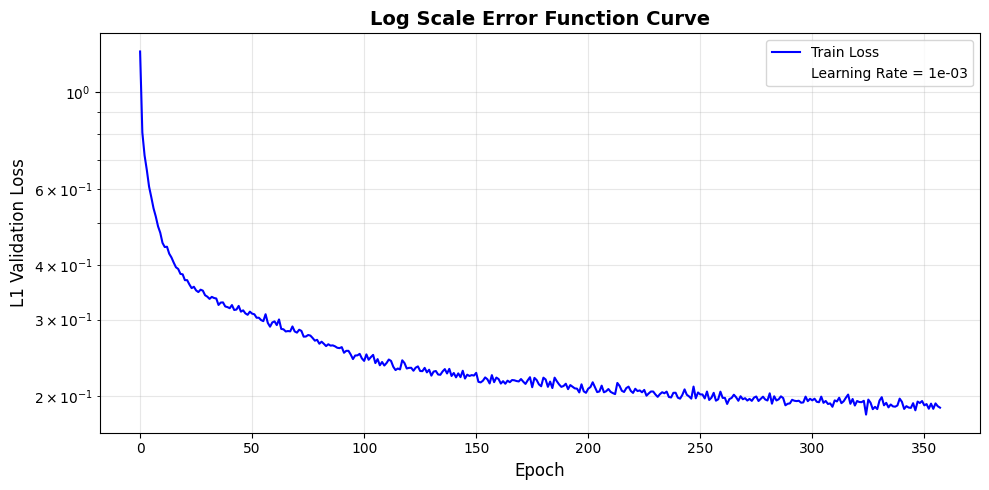

In [368]:
current_lr = optimizer.param_groups[0]['lr']
fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogy(force_train_hist,label='Train Loss',linewidth=1.5,color='blue')
ax.plot([], [], ' ', label=f'Learning Rate = {current_lr:.0e}')
ax.set_xlabel('Epoch',fontsize=12)
ax.set_ylabel('L1 Validation Loss',fontsize=12)
ax.set_title('Log Scale Error Function Curve',fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.3)  
plt.tight_layout()
plt.show()


*************************
Error Summary for Test Data
*************************
 Column              Mean %   Median %      Max %     < 5%    < 10%    < 20%
  -------------------------
  |P1| Max            24.65%     17.48%    253.08%    12.3%    29.0%    54.7%
  |B0| Max            23.69%     17.96%    235.25%    13.3%    29.7%    54.7%
  FOS                  0.92%      0.65%      9.29%    98.7%   100.0%   100.0%
  Torque              37.81%     21.26%    667.76%    13.0%    23.3%    48.3%
  QRR                  2.82%      1.74%     30.79%    85.7%    95.3%    99.7%
  dx                   0.81%      0.54%     10.47%    99.0%    99.7%   100.0%
  Bearing             16.37%     14.15%    130.74%    15.3%    34.7%    70.3%

*************************
Worst Predictions
*************************

  |P1| Max:
    Sample           True      Predicted    Error %
  -------------------------
       220        18.6616       -28.5668    253.08%
        74        15.1794       -18.9397    224.77%


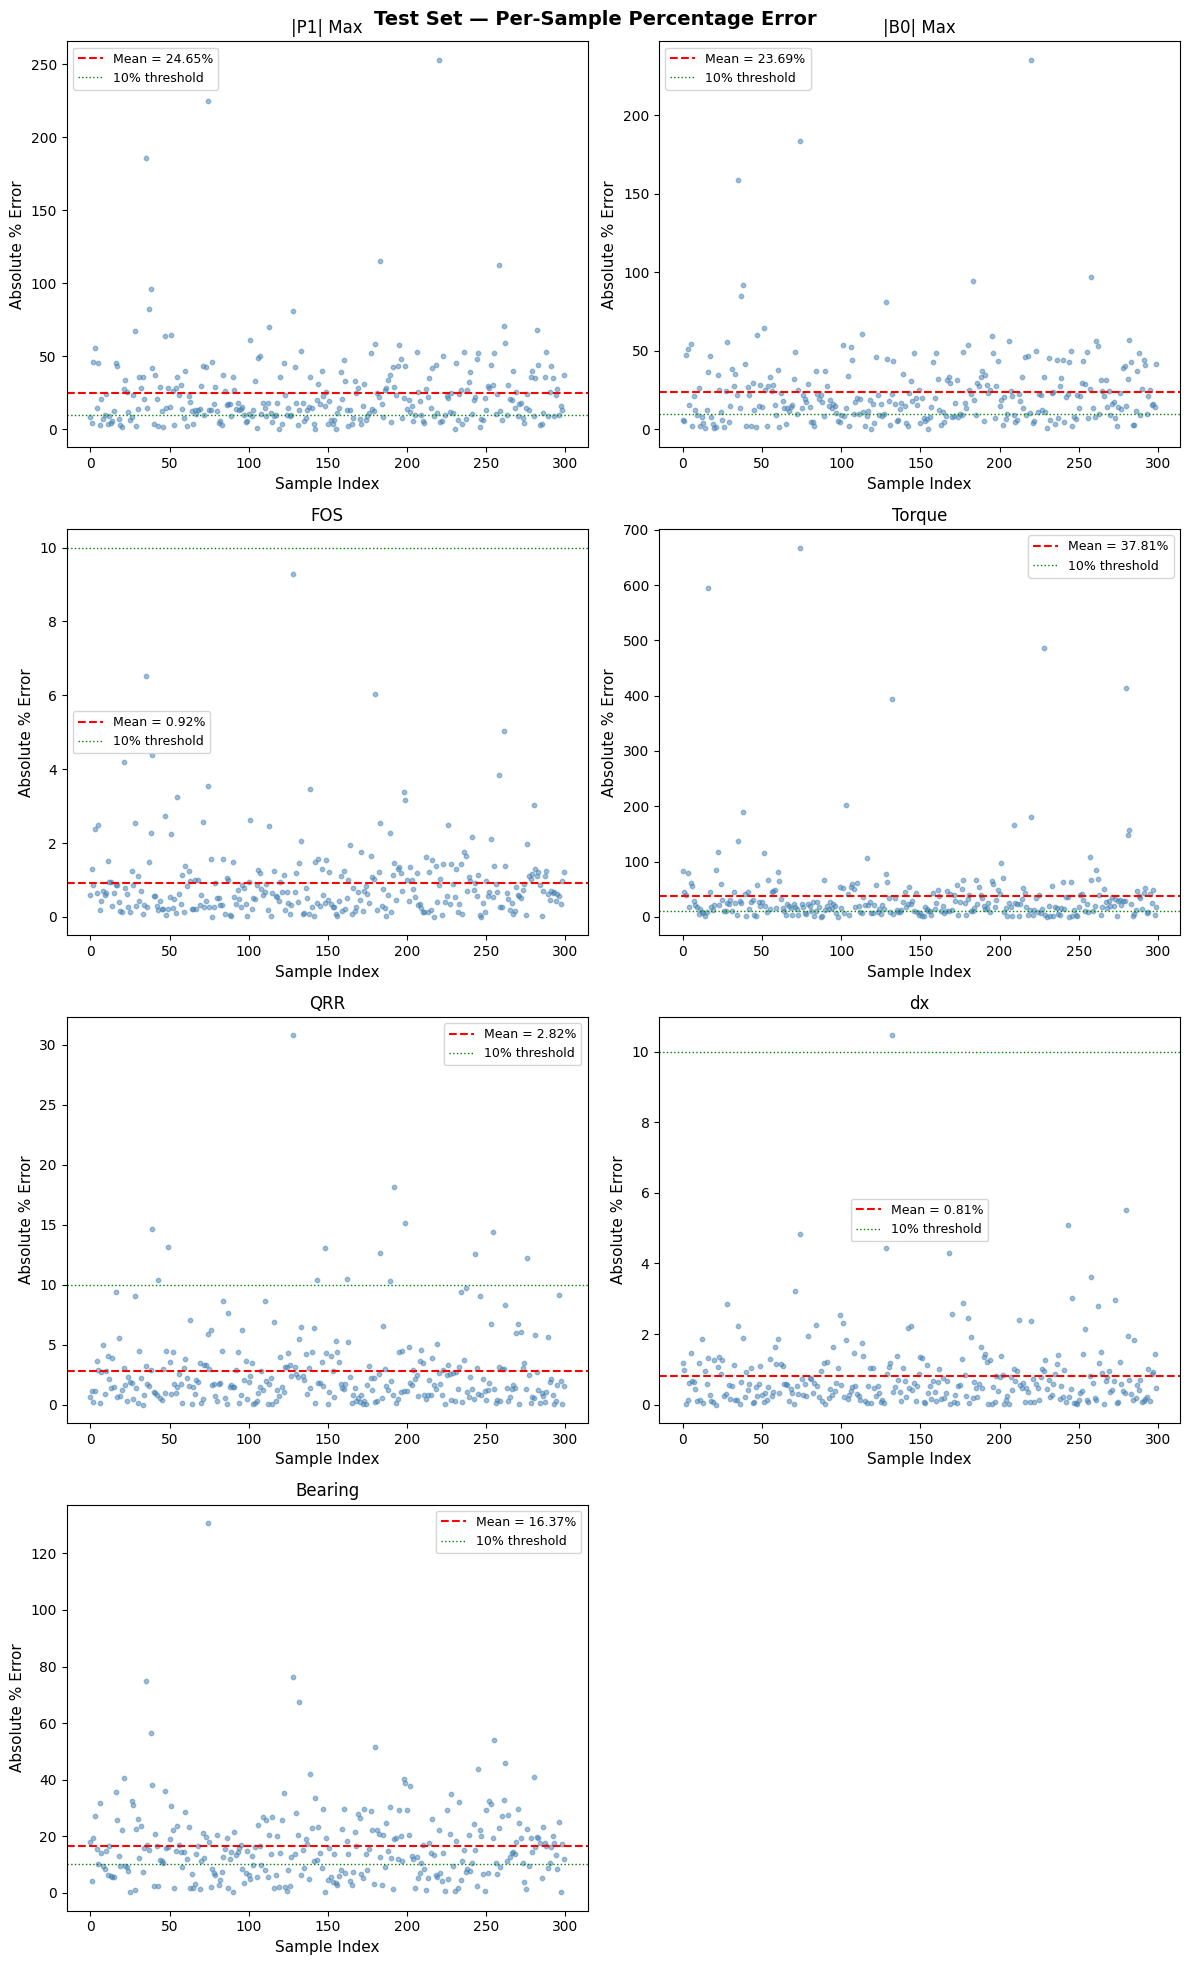

In [369]:
y_pred_real = (test_pred * y_std + y_mean).numpy()
y_true_real = (test_true * y_std + y_mean).numpy()
pct_error = np.abs(y_pred_real - y_true_real) / (np.abs(y_true_real) + 1e-8) * 100

print(f"\n{'*'*25}")
print(f"Error Summary for Test Data")
print(f"{'*'*25}")
print(f" {'Column':<15} {'Mean %':>10} {'Median %':>10} {'Max %':>10} {'< 5%':>8} {'< 10%':>8} {'< 20%':>8}")
print(f"  {'-'*25}")

for i, col in enumerate(out_col):
    col_pct = pct_error[:, i]
    mean_pct   = col_pct.mean()
    median_pct = np.median(col_pct)
    max_pct    = col_pct.max()
    within_5   = (col_pct < 5).sum() / len(col_pct) * 100
    within_10  = (col_pct < 10).sum() / len(col_pct) * 100
    within_20  = (col_pct < 20).sum() / len(col_pct) * 100
    print(f"  {col:<15} {mean_pct:>9.2f}% {median_pct:>9.2f}% {max_pct:>9.2f}% {within_5:>7.1f}% {within_10:>7.1f}% {within_20:>7.1f}%")

print(f"{'='*70}")

# ── 2. Worst predictions per target ──
print(f"\n{'*'*25}")
print(f"Worst Predictions")
print(f"{'*'*25}")

for i, col in enumerate(out_col):
    worst_idx = np.argsort(pct_error[:, i])[-5:][::-1]
    print(f"\n  {col}:")
    print(f"  {'Sample':>8} {'True':>14} {'Predicted':>14} {'Error %':>10}")
    print(f"  {'-'*25}")
    for idx in worst_idx:
        print(f"  {idx:>8} {y_true_real[idx, i]:>14.4f} {y_pred_real[idx, i]:>14.4f} {pct_error[idx, i]:>9.2f}%")

print(f"\n{'='*25}")

# ── 4. Plot: percentage error per sample (scatter) ──
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 5 * n_rows))
axes = axes.flatten()
for i, col in enumerate(out_col):
    ax = axes[i]
    col_pct = pct_error[:, i]
    ax.scatter(range(len(col_pct)), col_pct, alpha=0.5, s=10, color='steelblue')
    ax.axhline(col_pct.mean(), color='r', linestyle='--', linewidth=1.5, label=f'Mean = {col_pct.mean():.2f}%')
    ax.axhline(10, color='green', linestyle=':', linewidth=1, label='10% threshold')
    ax.set_xlabel('Sample Index', fontsize=11)
    ax.set_ylabel('Absolute % Error', fontsize=11)
    ax.set_title(f'{col}', fontsize=12)
    ax.legend(fontsize=9)
for j in range(len(out_col), len(axes)):axes[j].axis('off')
fig.suptitle('Test Set — Per-Sample Percentage Error', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

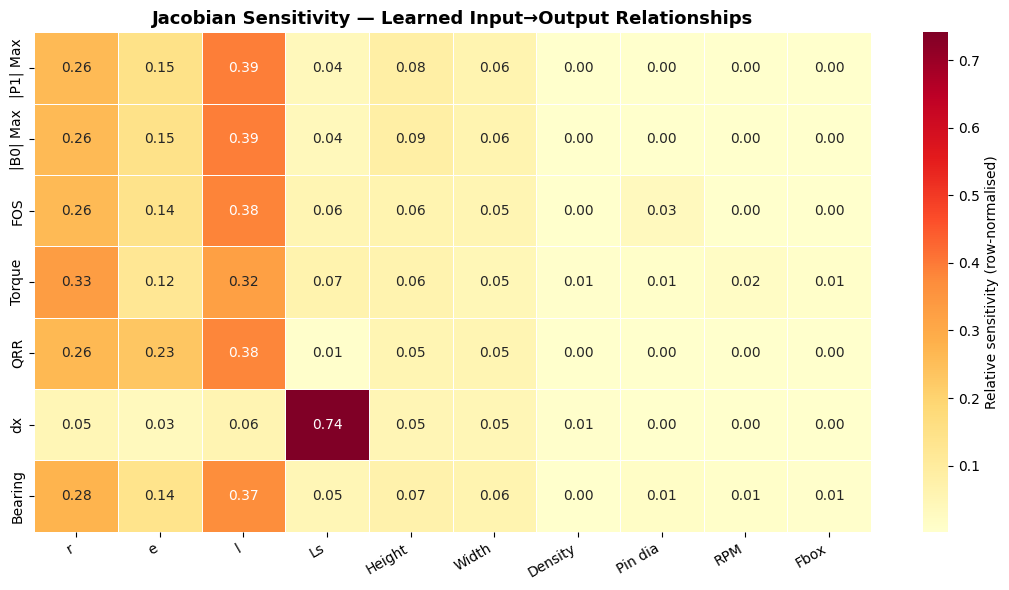

In [373]:
import torch, numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
X_t = torch.tensor(X_real, dtype=torch.float32, requires_grad=False)
X_norm = (X_t - x_mean) / x_std

jacobians = []  # one (n_output, n_input) per sample
for i in range(len(X_norm)):
    x_i = X_norm[i].unsqueeze(0).requires_grad_(True)
    y_i = model(x_i)  # (1, n_output)
    J = []
    for oi in range(n_output):
        grad = torch.autograd.grad(y_i[0, oi], x_i, retain_graph=True)[0]
        J.append(grad.detach().squeeze().numpy())
    jacobians.append(np.stack(J))  # (n_output, n_input)

J_mean = np.abs(np.stack(jacobians)).mean(axis=0)  # (n_output, n_input)

# Normalise rows so each output sums to 1 (like relative sensitivity)
J_norm = J_mean / J_mean.sum(axis=1, keepdims=True).clip(min=1e-8)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(J_norm, xticklabels=input_col, yticklabels=out_col,
            annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.4, linecolor="white",
            cbar_kws={"label": "Relative sensitivity (row-normalised)"})
ax.set_title("Jacobian Sensitivity — Learned Input→Output Relationships",
             fontsize=13, fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()